# LABORATORIO 6 - RECONSTRUCCIÓN DE MODELOS CON PYTORCH
# **1.- Laboratorio 2 Reconstruido con Pytorch. -**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# 1. Importación de librerías
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
import torch

# 2. Cargar el dataset con Pandas
df = pd.read_csv('/content/drive/MyDrive/DATASETS/diabetes_risk_prediction_dataset.csv')

# 3. Filtrar únicamente las columnas numéricas
df_numerico = df.select_dtypes(include=[np.number])

# 4. Eliminar la columna Patient_ID si existe
if 'Patient_ID' in df_numerico.columns:
    df_numerico = df_numerico.drop(columns=['Patient_ID'])

# 5. Eliminar filas que contengan valores nulos (nan)
df_numerico = df_numerico.dropna()

# 6. Separar la variable objetivo (y) de las características (X)
y_col = 'Diabetes_Risk_Score'

X = df_numerico.drop(columns=[y_col]).to_numpy()
y = df_numerico[y_col].to_numpy()

m = y.size
n = X.shape[1]

print(f"Número de muestras limpias (m): {m}")
print(f"Número de características numéricas (n): {n}\n")

print("Primeras 5 filas de X (sin NaNs):")
print(X[:5])
print("\nPrimeros 5 valores de y:")
print(y[:5])

Número de muestras limpias (m): 33689
Número de características numéricas (n): 20

Primeras 5 filas de X (sin NaNs):
[[ 32.  182.1  65.8  19.8  71.2  88.4  10.4 149.5  27.4  94.   61.  138.7
   40.1 152.3 250.8 119.    2.2 106.1   7.9   4.4]
 [ 42.  148.5 101.2  45.9 121.8 247.3  11.3 199.3  18.3 148.  100.  286.8
   35.6 110.4 287.9  59.    6.3  96.1   6.2   2.1]
 [ 87.  190.9  95.9  26.3  99.1  90.1   7.4 217.7  36.7 120.   63.  168.2
   61.9  63.4 308.8  58.    7.7  23.1   4.2   1.5]
 [ 27.  156.9 101.9  41.4  77.1  93.8  12.  153.5  22.3 190.   90.  281.5
   37.4  66.5 206.6 104.    4.7 131.2   9.9   1.6]
 [ 29.  153.3  86.3  36.7  77.1 142.2   5.  123.7  44.4 123.  119.  276.8
   54.6 121.9 385.5 112.    1.9  39.2   8.2   4.4]]

Primeros 5 valores de y:
[60 99 82 93 69]


In [ ]:
# 1. Definición de la función de normalización
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# 2. División en Train y Test(80% train, 20% test)
limit = int(0.8 * m)

X_train_raw = X[:limit]
X_test_raw  = X[limit:]

y_train_raw = y[:limit]
y_test_raw  = y[limit:]

# 3. Normalizamos las características de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train_raw)

# Normalizamos el test con la misma media y sigma de train
X_test_norm = (X_test_raw - mu) / sigma

# 4. Conversión a Tensores de PyTorch
X_train_t = torch.from_numpy(X_train_norm).float()
y_train_t = torch.from_numpy(y_train_raw).float().reshape(-1, 1)

X_test_t = torch.from_numpy(X_test_norm).float()
y_test_t = torch.from_numpy(y_test_raw).float().reshape(-1, 1)

print(f"Muestras de entrenamiento: {X_train_t.shape[0]}")
print(f"Muestras de prueba: {X_test_t.shape[0]}")

Muestras de entrenamiento: 26951
Muestras de prueba: 6738


In [ ]:
from torch.utils.data import Dataset, DataLoader

class DiabetesDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.from_numpy(X_data).float()
        self.y = torch.from_numpy(y_data).float().reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instanciamos los datasets
train_dataset = DiabetesDataset(X_train_norm, y_train_raw)
test_dataset  = DiabetesDataset(X_test_norm, y_test_raw)

# Crear DataLoaders (Lotes de 64 muestras)
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Número de lotes (batches) de entrenamiento: {len(train_loader)}")
print(f"Número de lotes (batches) de prueba: {len(test_loader)}")

Número de lotes (batches) de entrenamiento: 422
Número de lotes (batches) de prueba: 106


In [ ]:
import torch.nn as nn

D_in = X_train_norm.shape[1]  # 20
D_out = 1                 # 1

# Modelo de Regresión Lineal pura en PyTorch
model = nn.Sequential(
    nn.Linear(D_in, D_out)
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("Estructura del modelo:")
print(model)
print(f"\nDispositivo utilizado: {device}")

Estructura del modelo:
Sequential(
  (0): Linear(in_features=20, out_features=1, bias=True)
)

Dispositivo utilizado: cuda


In [ ]:
epochs = 50
loss_history = []

model.train()
for epoch in range(1, epochs + 1):
    batch_losses = []

    # Recorrer los lotes entregados por el DataLoader
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward y Optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    # Pérdida promedio del epoch
    epoch_loss = np.mean(batch_losses)
    loss_history.append(epoch_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - Loss (MSE): {epoch_loss:.4f}")

Epoch 1/50 - Loss (MSE): 461.0170
Epoch 5/50 - Loss (MSE): 123.7373
Epoch 10/50 - Loss (MSE): 123.7077
Epoch 15/50 - Loss (MSE): 123.7017
Epoch 20/50 - Loss (MSE): 123.6450
Epoch 25/50 - Loss (MSE): 123.5600
Epoch 30/50 - Loss (MSE): 123.6274
Epoch 35/50 - Loss (MSE): 123.4966
Epoch 40/50 - Loss (MSE): 123.5943
Epoch 45/50 - Loss (MSE): 123.7470
Epoch 50/50 - Loss (MSE): 123.8912


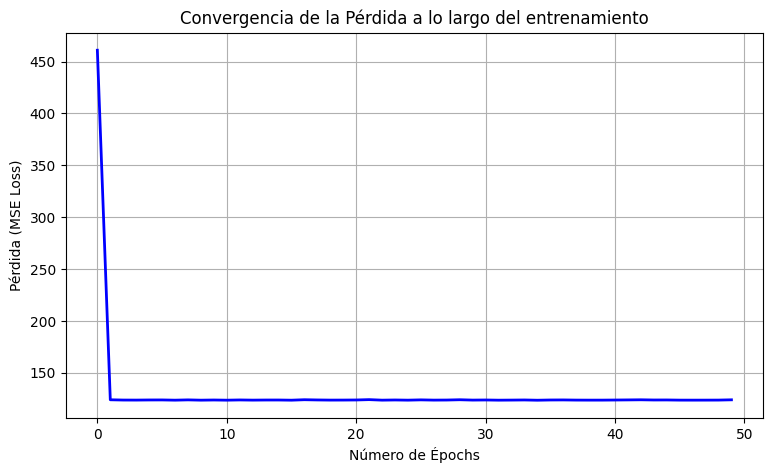

In [ ]:
# Graficar la curva de aprendizaje (Loss vs Épochs)
pyplot.figure(figsize=(9, 5))
pyplot.plot(np.arange(len(loss_history)), loss_history, '-b', lw=2)
pyplot.xlabel('Número de Épochs')
pyplot.ylabel('Pérdida (MSE Loss)')
pyplot.title('Convergencia de la Pérdida a lo largo del entrenamiento')
pyplot.grid(True)
pyplot.show()

In [ ]:
model.eval()
test_losses = []
all_y_true = []
all_y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)
        test_losses.append(loss.item())

        all_y_true.append(y_batch.cpu())
        all_y_pred.append(y_pred.cpu())

y_true_all = torch.cat(all_y_true, dim=0)
y_pred_all = torch.cat(all_y_pred, dim=0)

mse_test = np.mean(test_losses)
u = ((y_true_all - y_pred_all) ** 2).sum()
v = ((y_true_all - y_true_all.mean()) ** 2).sum()
r2_score = (1 - (u / v)).item()

print("--- EVALUACIÓN EN CONJUNTO DE PRUEBA ---")
print(f"Error Cuadrático Medio en Test (MSE): {mse_test:.4f}")
print(f"Coeficiente R² de rendimiento: {r2_score * 100:.2f}%")

--- EVALUACIÓN EN CONJUNTO DE PRUEBA ---
Error Cuadrático Medio en Test (MSE): 127.4312
Coeficiente R² de rendimiento: 47.52%


In [ ]:
weights_path = "modelo_regresion_lineal.pth"
torch.save(model.state_dict(), weights_path)

print(f"Pesos guardados exitosamente en: '{weights_path}'")

Pesos guardados exitosamente en: 'modelo_regresion_lineal.pth'


# **2.- Laboratorio 3 Reconstruido con Pytorch. -**

In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
import torch


In [ ]:

# 1. Cargar el dataset de FIFA 22
df = pd.read_csv('/content/drive/MyDrive/DATASETS/players_22.csv', low_memory=False)

# 2. Selección de 13 características numéricas y la etiqueta y
feature_cols = [
    'overall', 'potential', 'age', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling', 'defending',
    'physic', 'skill_moves', 'international_reputation'
]
target_col = 'value_eur'

# 3. Filtrar y eliminar valores nulos (NaN)
df_clean = df[feature_cols + [target_col]].dropna()

# 4. Extracción de matrices NumPy
X_raw = df_clean[feature_cols].values
y = df_clean[target_col].values
m = y.size
n = X_raw.shape[1]

print("CARGA DE DATOS EXITOSA")
print(f"Número de ejemplos (m): {m}")
print(f"Número de características (n): {n}")
print(f"Forma de X_raw: {X_raw.shape}")
print(f"Forma de y: {y.shape}")

CARGA DE DATOS EXITOSA
Número de ejemplos (m): 17041
Número de características (n): 13
Forma de X_raw: (17041, 13)
Forma de y: (17041,)


**División Train / Test (80/20) y Normalización $Z$-score**

In [ ]:
# 1. División Train/Test 80/20
limit = int(0.8 * m)

X_train_raw, X_test_raw = X_raw[:limit], X_raw[limit:]
y_train_raw, y_test_raw = y[:limit], y[limit:]

# 2. Función Z-score ajustada para vectores 1D y matrices 2D
def ZScore(data):
    mu = np.mean(data, axis=0)
    sigma = np.std(data, axis=0)

    # Manejo de cero tanto si sigma es escalar como si es un vector NumPy
    if np.isscalar(sigma):
        if sigma == 0:
            sigma = 1.0
    else:
        sigma[sigma == 0] = 1.0

    return (data - mu) / sigma, mu, sigma

# Normalización de entradas X
X_train_norm, mu_X, sigma_X = ZScore(X_train_raw)
X_test_norm = (X_test_raw - mu_X) / sigma_X

# Normalización de salida y (para estabilizar SGD)
y_train_norm, mu_y, sigma_y = ZScore(y_train_raw)
y_test_norm = (y_test_raw - mu_y) / sigma_y

print("DATOS E Y NORMALIZADOS CORRECTAMENTE PARA SGD")

DATOS E Y NORMALIZADOS CORRECTAMENTE PARA SGD


**Definición del Dataset y DataLoader de PyTorch**

In [ ]:
from torch.utils.data import Dataset, DataLoader

class FIFADataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.from_numpy(X_data).float()
        self.y = torch.from_numpy(y_data).float().reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FIFADataset(X_train_norm, y_train_norm)
test_dataset  = FIFADataset(X_test_norm, y_test_norm)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print("DATALOADERS CREADOS CORRECTAMENTE")

DATALOADERS CREADOS CORRECTAMENTE


**Regresion Lineal Multivariable**

Epoch 1/100 - Loss (MSE estandarizado): 1.12872
Epoch 10/100 - Loss (MSE estandarizado): 0.42777
Epoch 20/100 - Loss (MSE estandarizado): 0.41966
Epoch 30/100 - Loss (MSE estandarizado): 0.41677
Epoch 40/100 - Loss (MSE estandarizado): 0.41502
Epoch 50/100 - Loss (MSE estandarizado): 0.41417
Epoch 60/100 - Loss (MSE estandarizado): 0.41352
Epoch 70/100 - Loss (MSE estandarizado): 0.41345
Epoch 80/100 - Loss (MSE estandarizado): 0.41312
Epoch 90/100 - Loss (MSE estandarizado): 0.41323
Epoch 100/100 - Loss (MSE estandarizado): 0.41309


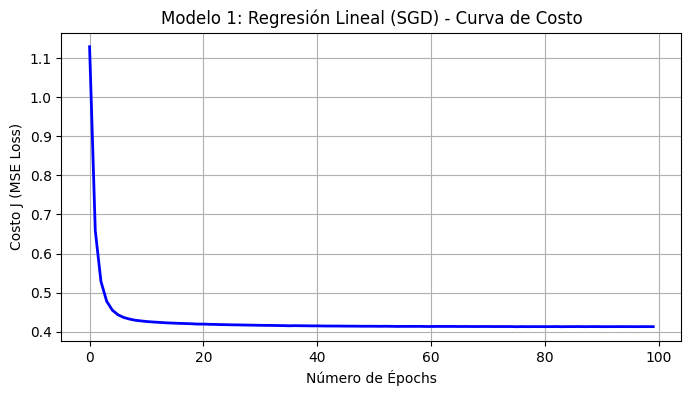

In [ ]:
import torch.nn as nn

D_in = X_train_norm.shape[1]
D_out = 1

model1 = nn.Sequential(
    nn.Linear(D_in, D_out)
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model1.to(device)

criterion = nn.MSELoss()
epochs = 100
lr = 0.001

# Optimizador SGD estricto de PyTorch
optimizer1 = torch.optim.SGD(model1.parameters(), lr=lr)

J_history1 = []

model1.train()
for epoch in range(1, epochs + 1):
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward
        y_pred = model1(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward y Optimización
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()

        batch_losses.append(loss.item())

    epoch_loss = np.mean(batch_losses)
    J_history1.append(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - Loss (MSE estandarizado): {epoch_loss:.5f}")

# Gráfica de convergencia del costo J
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history1)), J_history1, lw=2, color='blue')
pyplot.xlabel('Número de Épochs')
pyplot.ylabel('Costo J (MSE Loss)')
pyplot.title('Modelo 1: Regresión Lineal (SGD) - Curva de Costo')
pyplot.grid(True)
pyplot.show()

In [ ]:
model1.eval()
test_loss = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        predictions = model1(X_batch)
        loss = criterion(predictions, y_batch)
        test_loss += loss.item() * X_batch.size(0)

mse_test = test_loss / len(test_loader.dataset)
rmse_euros = np.sqrt(mse_test) * sigma_y

print("--- EVALUACIÓN MODELO 1 ---")
print(f"Costo final en Test (MSE Estandarizado): {mse_test:.4f}")
print(f"Error Promedio Estimado (RMSE): {rmse_euros:,.2f} €")

--- EVALUACIÓN MODELO 1 ---
Costo final en Test (MSE Estandarizado): 0.4441
Error Promedio Estimado (RMSE): 5,666,132.51 €


**MODELO 2 : Regresion Polinómica**

Epoch 1/100 - Loss (MSE Estandarizado): 0.73782
Epoch 10/100 - Loss (MSE Estandarizado): 0.39048
Epoch 20/100 - Loss (MSE Estandarizado): 0.37972
Epoch 30/100 - Loss (MSE Estandarizado): 0.37235
Epoch 40/100 - Loss (MSE Estandarizado): 0.36672
Epoch 50/100 - Loss (MSE Estandarizado): 0.36195
Epoch 60/100 - Loss (MSE Estandarizado): 0.35753
Epoch 70/100 - Loss (MSE Estandarizado): 0.35344
Epoch 80/100 - Loss (MSE Estandarizado): 0.34944
Epoch 90/100 - Loss (MSE Estandarizado): 0.34565
Epoch 100/100 - Loss (MSE Estandarizado): 0.34219


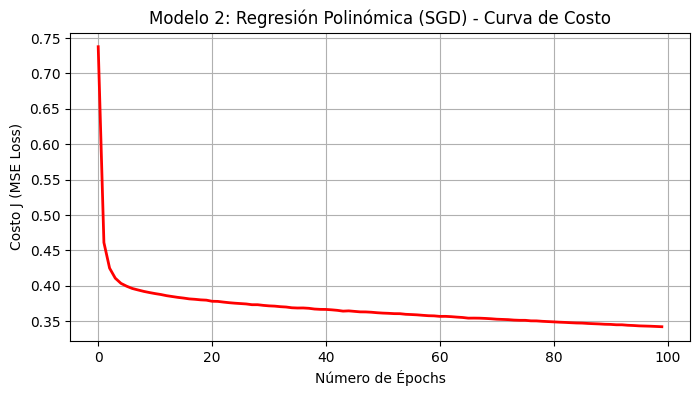

=== MODELO 2 COMPLETADO EN PYTORCH ===
Costo inicial J: 0.73782
Costo final alcanzado J: 0.34219


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from matplotlib import pyplot
from torch.utils.data import Dataset, DataLoader

# 1. Creación de características polinómicas (X y X^2)
X_poly = np.concatenate([X_raw, X_raw ** 2], axis=1)

# 2. División Train / Test (80/20)
limit = int(0.8 * m)

X_train_poly_raw, X_test_poly_raw = X_poly[:limit], X_poly[limit:]
y_train_raw, y_test_raw = y[:limit], y[limit:]

# 3. Normalización Z-Score de características polinómicas e 'y'
X_train_poly_norm, mu_poly, sigma_poly = ZScore(X_train_poly_raw)
X_test_poly_norm = (X_test_poly_raw - mu_poly) / sigma_poly

y_train_norm, mu_y, sigma_y = ZScore(y_train_raw)
y_test_norm = (y_test_raw - mu_y) / sigma_y

# 4. Dataset y DataLoader para la Regresión Polinómica
class FIFAPolyDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.from_numpy(X_data).float()
        self.y = torch.from_numpy(y_data).float().reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_poly_dataset = FIFAPolyDataset(X_train_poly_norm, y_train_norm)
test_poly_dataset  = FIFAPolyDataset(X_test_poly_norm, y_test_norm)

train_poly_loader = DataLoader(dataset=train_poly_dataset, batch_size=64, shuffle=True)
test_poly_loader  = DataLoader(dataset=test_poly_dataset, batch_size=64, shuffle=False)

# 5. Definición del Modelo Polinómico en PyTorch
D_in_poly = X_train_poly_norm.shape[1]  # 26 características (13 originales + 13 al cuadrado)
D_out = 1

model2 = nn.Sequential(
    nn.Linear(D_in_poly, D_out)
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model2.to(device)

# 6. Configuración de Hiperparámetros, Costo y Optimizador SGD
criterion = nn.MSELoss()
epochs = 100
lr = 0.001

optimizer2 = torch.optim.SGD(model2.parameters(), lr=lr)

# 7. Bucle de Entrenamiento
J_history2 = []

model2.train()
for epoch in range(1, epochs + 1):
    batch_losses = []
    for X_batch, y_batch in train_poly_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward
        y_pred = model2(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward y Optimización
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        batch_losses.append(loss.item())

    epoch_loss = np.mean(batch_losses)
    J_history2.append(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - Loss (MSE Estandarizado): {epoch_loss:.5f}")

# 8. Gráfica de convergencia del costo J(theta)
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history2)), J_history2, lw=2, color='red')
pyplot.xlabel('Número de Épochs')
pyplot.ylabel('Costo J (MSE Loss)')
pyplot.title('Modelo 2: Regresión Polinómica (SGD) - Curva de Costo')
pyplot.grid(True)
pyplot.show()

# 9. Muestra de resultados
print("=== MODELO 2 COMPLETADO EN PYTORCH ===")
print(f"Costo inicial J: {J_history2[0]:.5f}")
print(f"Costo final alcanzado J: {J_history2[-1]:.5f}")

In [ ]:
# 1. Seleccionar un jugador real del dataset para probar
# (Por ejemplo, el primer jugador del dataset o una estrella)
idx_prueba = 0

jugador_info = df_clean.iloc[idx_prueba]
x_ejemplo_raw = X_raw[idx_prueba]          # Sus 13 características originales
valor_real_euros = y[idx_prueba]           # Su valor real en el dataset

# 2. Paso Polinómico: Concatenar X y X^2
x_ejemplo_poly = np.concatenate([x_ejemplo_raw, x_ejemplo_raw ** 2])

# 3. Estandarización usando los parámetros guardados de Train (mu_poly, sigma_poly)
x_ejemplo_norm = (x_ejemplo_poly - mu_poly) / sigma_poly

# 4. Convertir a Tensor de PyTorch (1, 26)
x_tensor = torch.from_numpy(x_ejemplo_norm).float().unsqueeze(0).to(device)

# 5. Predicción con el Modelo 2 (Polinómico)
model2.eval()
with torch.no_grad():
    y_pred_norm = model2(x_tensor).cpu().item()

# 6. Des-normalización para obtener el valor en Euros reales
valor_predicho_euros = (y_pred_norm * sigma_y) + mu_y

# 7. Mostrar comparación de resultados
diferencia = abs(valor_real_euros - valor_predicho_euros)

print("="*50)
print(f"--- PREDICCIÓN CON MODELO POLINÓMICO (PyTorch) ---")
print("="*50)
print(f"Overall (Media de habilidad): {jugador_info['overall']}")
print(f"Potential (Potencial):        {jugador_info['potential']}")
print(f"Edad:                         {jugador_info['age']} años")
print("-" * 50)
print(f"VALOR REAL EN DATASET:        {valor_real_euros:,.2f} €")
print(f"VALOR PREDICHO POR EL MODELO: {valor_predicho_euros:,.2f} €")
print(f"Diferencia / Margen de error: {diferencia:,.2f} €")
print("="*50)

--- PREDICCIÓN CON MODELO POLINÓMICO (PyTorch) ---
Overall (Media de habilidad): 93.0
Potential (Potencial):        93.0
Edad:                         34.0 años
--------------------------------------------------
VALOR REAL EN DATASET:        78,000,000.00 €
VALOR PREDICHO POR EL MODELO: 80,599,340.59 €
Diferencia / Margen de error: 2,599,340.59 €


# **3.- Laboratorio 4 Reconstruido con Pytorch**

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot

# 1. Cargar dataset con Pandas
df = pd.read_csv('/content/drive/MyDrive/DATASETS/OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()

# 2. Binarizar variable objetivo (1 = Popular, 0 = No Popular)
df['target'] = (df['shares'] >= 1400).astype(int)

# 3. Limpiar columnas no utilizables
df_clean = df.drop(columns=['url', 'timedelta', 'shares'])

# Convertir a arreglos NumPy
X_raw = df_clean.drop(columns=['target']).values
y_raw = df_clean['target'].values

# 4. División 80% Entrenamiento y 20% Prueba
m_total = X_raw.shape[0]
train_size = int(m_total * 0.8)

X_train_raw = X_raw[:train_size]
y_train = y_raw[:train_size]

X_test_raw = X_raw[train_size:]
y_test = y_raw[train_size:]

# 5. Normalización Z-Score de X (y no se normaliza por ser binaria)
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train_raw)
X_test_norm = (X_test_raw - mu) / sigma

# 6. Dataset y DataLoader para PyTorch
class NewsDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.from_numpy(X_data).float()
        self.y = torch.from_numpy(y_data).float().reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = NewsDataset(X_train_norm, y_train)
test_dataset  = NewsDataset(X_test_norm, y_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print("=== PREPARACIÓN DE DATOS EN PYTORCH COMPLETADA ===")
print(f"Muestras de entrenamiento: {len(train_dataset)}")
print(f"Muestras de prueba:        {len(test_dataset)}")
print(f"Características de entrada (D_in): {X_train_norm.shape[1]}")

=== PREPARACIÓN DE DATOS EN PYTORCH COMPLETADA ===
Muestras de entrenamiento: 31715
Muestras de prueba:        7929
Características de entrada (D_in): 58


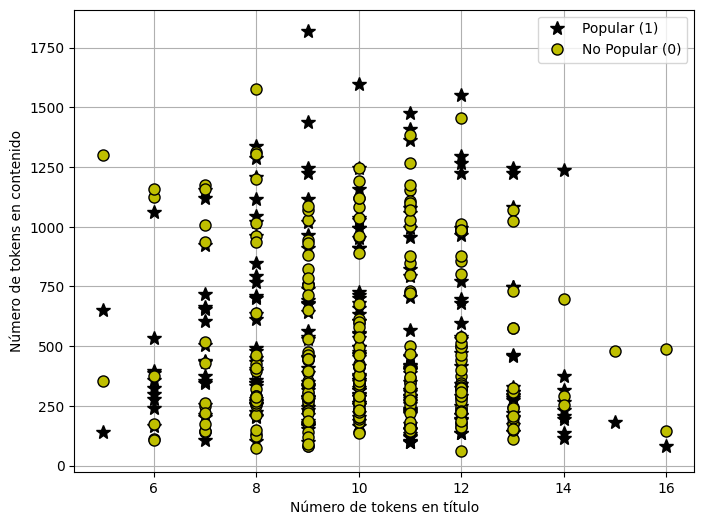

In [ ]:
import matplotlib.pyplot as plt

def plotData(X, y):
    fig = plt.figure(figsize=(8, 6))
    pos = (y == 1)
    neg = (y == 0)

    # Se grafican las dos primeras características para visualización
    plt.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10, label='Popular (1)')
    plt.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1, label='No Popular (0)')

    plt.xlabel('Número de tokens en título')
    plt.ylabel('Número de tokens en contenido')
    plt.legend()
    plt.grid(True)
    plt.show()

# Graficar muestra de los datos sin normalizar (primeros 500 ejemplos)
plotData(X_train_raw[:500], y_train[:500])

In [ ]:
# Confirmación de la división 80% Train y 20% Test realizada
m_train = len(train_dataset)
m_test = len(test_dataset)
m_total_samples = m_train + m_test

print(f"Total de datos: {m_total_samples}")
print(f"Conjunto de entrenamiento (80%): {m_train} ejemplos")
print(f"Conjunto de prueba (20%): {m_test} ejemplos")

Total de datos: 39644
Conjunto de entrenamiento (80%): 31715 ejemplos
Conjunto de prueba (20%): 7929 ejemplos


In [ ]:
import torch
import torch.nn as nn

# 1. Definición de la arquitectura del Modelo Logístico Binario
D_in = X_train_norm.shape[1]  # Número de características de entrada
D_out = 1                     # Salida binaria (probabilidad entre 0 y 1)

model_logistic = nn.Sequential(
    nn.Linear(D_in, D_out),
    nn.Sigmoid()  # Función de activación Sigmoide g(z)
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_logistic.to(device)

# 2. Definición de la Función de Costo (Entropía Cruzada Binaria / BCE)
criterion_bce = nn.BCELoss()

# 3. Inicialización manual de pesos en ceros para validar el costo inicial (theta = 0)
with torch.no_grad():
    model_logistic[0].weight.zero_()
    model_logistic[0].bias.zero_()

# 4. Cálculo del costo inicial sobre el primer batch de datos
model_logistic.eval()
with torch.no_grad():
    X_batch, y_batch = next(iter(train_loader))
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    y_pred_inicial = model_logistic(X_batch)
    costo_inicial = criterion_bce(y_pred_inicial, y_batch).item()

print(f"Número total de atributos (D_in): {D_in}")
print(f"Costo inicial con theta = 0 (BCE Loss): {costo_inicial:.4f}")

Número total de atributos (D_in): 58
Costo inicial con theta = 0 (BCE Loss): 0.6931


Época 1/100 - Costo (BCE Loss): 0.6495
Época 10/100 - Costo (BCE Loss): 0.6274
Época 20/100 - Costo (BCE Loss): 0.6261
Época 30/100 - Costo (BCE Loss): 0.6255
Época 40/100 - Costo (BCE Loss): 0.6253
Época 50/100 - Costo (BCE Loss): 0.6253
Época 60/100 - Costo (BCE Loss): 0.6251
Época 70/100 - Costo (BCE Loss): 0.6252
Época 80/100 - Costo (BCE Loss): 0.6252
Época 90/100 - Costo (BCE Loss): 0.6251
Época 100/100 - Costo (BCE Loss): 0.6252

Costo final tras 100 épocas: 0.6252


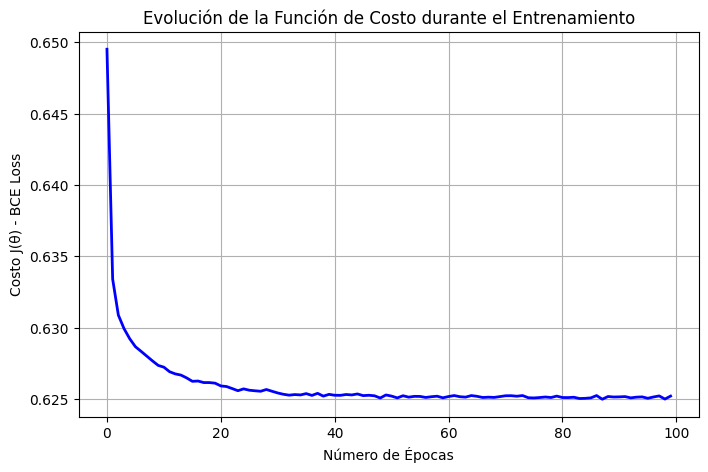

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Hiperparámetros de entrenamiento
alpha = 0.01
epochs = 100  # Con minibatches, 100 épocas equivalen a miles de actualizaciones

# 2. Optimizador SGD
optimizer = torch.optim.SGD(model_logistic.parameters(), lr=alpha)

# 3. Bucle de Entrenamiento
J_history = []

model_logistic.train()
for epoch in range(1, epochs + 1):
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass (predicción y cálculo de pérdida)
        y_pred = model_logistic(X_batch)
        loss = criterion_bce(y_pred, y_batch)

        # Backward pass y actualización de pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    # Calcular costo promedio de la época
    epoch_loss = np.mean(batch_losses)
    J_history.append(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Época {epoch}/{epochs} - Costo (BCE Loss): {epoch_loss:.4f}")

print(f"\nCosto final tras {epochs} épocas: {J_history[-1]:.4f}")

# 4. Gráfica del costo respecto a las iteraciones/épocas
plt.figure(figsize=(8, 5))
plt.plot(range(len(J_history)), J_history, color='blue', linewidth=2)
plt.xlabel('Número de Épocas')
plt.ylabel('Costo J(θ) - BCE Loss')
plt.title('Evolución de la Función de Costo durante el Entrenamiento')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import torch

model_logistic.eval()

# 1. Obtener predicciones en Entrenamiento
y_train_preds = []
y_train_trues = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        probs = model_logistic(X_batch)
        preds = (probs >= 0.5).float()

        y_train_preds.append(preds.cpu())
        y_train_trues.append(y_batch)

y_train_pred_all = torch.cat(y_train_preds, dim=0).numpy().ravel()
y_train_true_all = torch.cat(y_train_trues, dim=0).numpy().ravel()

# 2. Obtener predicciones en Prueba (Test)
y_test_preds = []
y_test_trues = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs = model_logistic(X_batch)
        preds = (probs >= 0.5).float()

        y_test_preds.append(preds.cpu())
        y_test_trues.append(y_batch)

y_test_pred_all = torch.cat(y_test_preds, dim=0).numpy().ravel()
y_test_true_all = torch.cat(y_test_trues, dim=0).numpy().ravel()

# 3. Cálculo de la precisión (Accuracy)
acc_train = np.mean(y_train_pred_all == y_train_true_all) * 100
acc_test = np.mean(y_test_pred_all == y_test_true_all) * 100

print(f"Precisión en el conjunto de Entrenamiento (80%): {acc_train:.2f}%")
print(f"Precisión en el conjunto de Prueba (20%): {acc_test:.2f}%")

# 4. Muestra comparativa sobre las primeras 10 muestras del conjunto de prueba
df_resultado = pd.DataFrame({
    'Predicción del Modelo': y_test_pred_all[:10].astype(int),
    'Valor Real (y_test)': y_test_true_all[:10].astype(int)
})

print("\n--- Comparativa de Predicciones vs Valores Reales (Test) ---")
print(df_resultado)

Precisión en el conjunto de Entrenamiento (80%): 65.37%
Precisión en el conjunto de Prueba (20%): 65.63%

--- Comparativa de Predicciones vs Valores Reales (Test) ---
   Predicción del Modelo  Valor Real (y_test)
0                      1                    1
1                      1                    0
2                      1                    1
3                      0                    0
4                      0                    0
5                      0                    0
6                      0                    0
7                      0                    0
8                      0                    0
9                      1                    0


# **4.- Laboratorio 5 Reconstruido con Pytorch**

In [ ]:
import scipy.io

ruta_archivo = '/content/drive/MyDrive/DATASETS/dataset_laboratorio.mat'

# Cargar el dataset
mat_data = scipy.io.loadmat(ruta_archivo)
print("¡Archivo cargado con éxito!")
print("Variables dentro del .mat:", mat_data.keys())

¡Archivo cargado con éxito!
Variables dentro del .mat: dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


In [ ]:
import torch

# 1. Extraer los datos de las llaves
X_np = mat_data['X']
y_np = mat_data['y']

print(f"Tipo original de X: {type(X_np)}, Forma (shape): {X_np.shape}")
print(f"Tipo original de y: {type(y_np)}, Forma (shape): {y_np.shape}")

# 2. Convertir los arreglos de NumPy a Tensores de PyTorch
X_tensor = torch.from_numpy(X_np).float()
y_tensor = torch.from_numpy(y_np).long()

print("\n--- ¡Conversión exitosa a PyTorch! ---")
print(f"Tensor de entradas X: {X_tensor.shape}, tipo: {X_tensor.dtype}")
print(f"Tensor de etiquetas y: {y_tensor.shape}, tipo: {y_tensor.dtype}")

Tipo original de X: <class 'numpy.ndarray'>, Forma (shape): (75000, 784)
Tipo original de y: <class 'numpy.ndarray'>, Forma (shape): (75000, 1)

--- ¡Conversión exitosa a PyTorch! ---
Tensor de entradas X: torch.Size([75000, 784]), tipo: torch.float32
Tensor de etiquetas y: torch.Size([75000, 1]), tipo: torch.int64


In [ ]:
import torch

D_in = 784          # 28x28 píxeles de entrada
H = 100             # Neuronas en la capa oculta
D_out = 5  # Número de clases reales de arroz

# 2. Definición del modelo Perceptrón Multicapa
model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

# 3. Prueba rápida de propagación directa (Forward pass) con datos aleatorios
outputs = model(torch.randn(600, 784))
print("Forma de las salidas de prueba (shape):", outputs.shape)
print("Salida para la primera muestra:", outputs[0][:])

# 4. Muestra la estructura del modelo
print("\nEstructura del modelo:")
print(model)

# 5. Enviar el modelo a la GPU (CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"\n¡Modelo cargado exitosamente en el dispositivo: {device}!")

Forma de las salidas de prueba (shape): torch.Size([600, 5])
Salida para la primera muestra: tensor([-0.2074,  0.0554, -0.5337,  0.3069, -0.2635], grad_fn=<SliceBackward0>)

Estructura del modelo:
Sequential(
  (0): Linear(in_features=784, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=5, bias=True)
)

¡Modelo cargado exitosamente en el dispositivo: cuda!


In [ ]:
import numpy as np
import torch

# 1. Crear una permutación aleatoria de índices para mezclar las 75,000 imágenes
np.random.seed(42)  # Para asegurar que la mezcla sea reproducible
m_total = X_np.shape[0]
indices_mezclados = np.random.permutation(m_total)

X_np_shuffled = X_np[indices_mezclados]
y_np_shuffled = y_np[indices_mezclados].squeeze().astype(np.int64)

# Ajuste por si el .mat venía en rango 1-5
if y_np_shuffled.min() == 1:
    y_np_shuffled = y_np_shuffled - 1

# 2. División 80% Train (60,000) y 20% Test (15,000) YA MEZCLADOS
X_train_np = X_np_shuffled[:60000] / 255.
X_test_np  = X_np_shuffled[60000:] / 255.

y_train_np = y_np_shuffled[:60000]
y_test_np  = y_np_shuffled[60000:]

# 3. Conversión a Tensores de PyTorch
X_train = torch.from_numpy(X_train_np).float()
X_test  = torch.from_numpy(X_test_np).float()
y_train = torch.from_numpy(y_train_np).long()
y_test  = torch.from_numpy(y_test_np).long()

print("--- DATOS MEZCLADOS Y PREPARADOS CORRECTAMENTE ---")
print(f"Clases presentes en Entrenamiento: {np.unique(y_train_np)}")
print(f"Clases presentes en Prueba (Test): {np.unique(y_test_np)}")

--- DATOS MEZCLADOS Y PREPARADOS CORRECTAMENTE ---
Clases presentes en Entrenamiento: [0 1 2 3 4]
Clases presentes en Prueba (Test): [0 1 2 3 4]


In [ ]:
import torch

# 1. Definición manual de Softmax
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

# 2. Definición manual de la Función de Pérdida (Cross Entropy)
def cross_entropy(output, target):
    logits = output[torch.arange(len(output)), target]
    loss = - logits + torch.log(torch.sum(torch.exp(output), axis=-1))
    loss = loss.mean()
    return loss

# 3. Comprobación rápida con una muestra de tus datos
print("Disponible:", torch.cuda.is_available())
print("\nMuestra de las imágenes de arroz (X_train):")
print(X_train)

Disponible: True

Muestra de las imágenes de arroz (X_train):
tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0078, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0078, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0078, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0078, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0078, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0078, 0.0000, 0.0000]])


In [ ]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-instanciar modelo para reiniciar pesos desde cero
model = torch.nn.Sequential(
    torch.nn.Linear(784, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 5)
).to(device)

X_t = X_train.to(device)
Y_t = y_train.to(device)

# Hiperparámetros corregidos
epochs = 350
lr = 0.05            # Tasa de aprendizaje ajustada a un valor estable
log_each = 10
loss_history = []

print(f"Iniciando entrenamiento en: {device}")

model.train()
for e in range(1, epochs + 1):

    # Forward
    y_pred = model(X_t)

    # Loss
    loss = cross_entropy(y_pred, Y_t)
    loss_history.append(loss.item())

    # Reset Gradientes
    model.zero_grad()

    # Backward
    loss.backward()

    # Actualización SGD
    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad

    # Mostrar la pérdida actual
    if not e % log_each:
        print(f"Epoch {e}/{epochs} - Loss actual: {loss.item():.5f}")

print("\n¡Entrenamiento completado exitosamente!")

Iniciando entrenamiento en: cuda
Epoch 10/350 - Loss actual: 1.54811
Epoch 20/350 - Loss actual: 1.48080
Epoch 30/350 - Loss actual: 1.40414
Epoch 40/350 - Loss actual: 1.31636
Epoch 50/350 - Loss actual: 1.22570
Epoch 60/350 - Loss actual: 1.13960
Epoch 70/350 - Loss actual: 1.06059
Epoch 80/350 - Loss actual: 0.98842
Epoch 90/350 - Loss actual: 0.92213
Epoch 100/350 - Loss actual: 0.86121
Epoch 110/350 - Loss actual: 0.80544
Epoch 120/350 - Loss actual: 0.75470
Epoch 130/350 - Loss actual: 0.70878
Epoch 140/350 - Loss actual: 0.66739
Epoch 150/350 - Loss actual: 0.63013
Epoch 160/350 - Loss actual: 0.59660
Epoch 170/350 - Loss actual: 0.56642
Epoch 180/350 - Loss actual: 0.53920
Epoch 190/350 - Loss actual: 0.51463
Epoch 200/350 - Loss actual: 0.49239
Epoch 210/350 - Loss actual: 0.47221
Epoch 220/350 - Loss actual: 0.45387
Epoch 230/350 - Loss actual: 0.43715
Epoch 240/350 - Loss actual: 0.42187
Epoch 250/350 - Loss actual: 0.40786
Epoch 260/350 - Loss actual: 0.39499
Epoch 270/350 

In [ ]:
import pandas as pd
import torch

# 1. Modo evaluación
model.eval()

with torch.no_grad():
    # Mover conjunto de prueba a la GPU
    X_test_gpu = X_test.to(device)

    # Forward pass sobre Test
    logits_test = model(X_test_gpu)

    # Obtener la clase con mayor probabilidad (argmax)
    preds_test = torch.argmax(logits_test, dim=1).cpu()

# 2. Cálculo del Accuracy sobre el 20% de prueba (15,000 imágenes)
y_test_cpu = y_test.cpu()
accuracy_test = (preds_test == y_test_cpu).float().mean().item() * 100

print("="*50)
print(f"EVALUACIÓN DEL MODELO EN EL CONJUNTO DE PRUEBA")
print("="*50)
print(f"Precisión Final (Accuracy): {accuracy_test:.2f}%")
print("="*50)

# 3. Muestra comparativa de las primeras 15 imágenes de prueba
df_resultados_arroz = pd.DataFrame({
    'Clase Predicha': preds_test[:15].numpy(),
    'Clase Real (y_test)': y_test_cpu[:15].numpy()
})

print("\n--- Comparativa de Predicciones vs Valores Reales (Test) ---")
print(df_resultados_arroz)

EVALUACIÓN DEL MODELO EN EL CONJUNTO DE PRUEBA
Precisión Final (Accuracy): 92.65%

--- Comparativa de Predicciones vs Valores Reales (Test) ---
    Clase Predicha  Clase Real (y_test)
0                1                    1
1                3                    3
2                0                    0
3                1                    3
4                3                    3
5                4                    4
6                3                    3
7                4                    4
8                4                    0
9                2                    2
10               1                    1
11               2                    2
12               1                    1
13               1                    1
14               4                    4


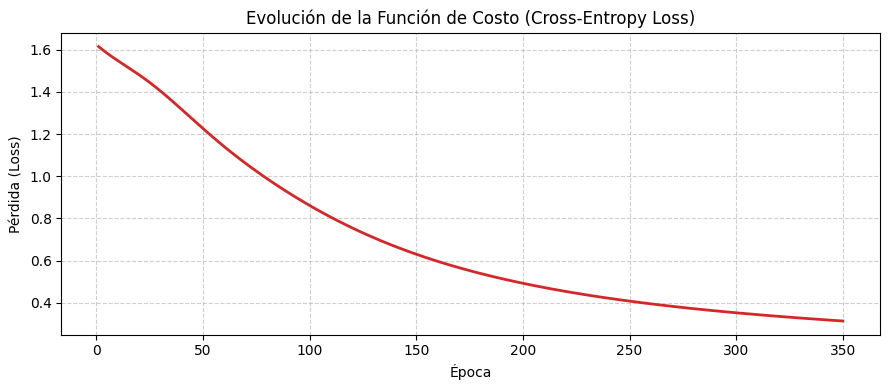

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. GRAFICA DE CONVERGENCIA DE LA PÉRDIDA (PÉRDIDA VS ÉPOCAS)
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, color='tab:red', linewidth=2)
plt.title('Evolución de la Función de Costo (Cross-Entropy Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



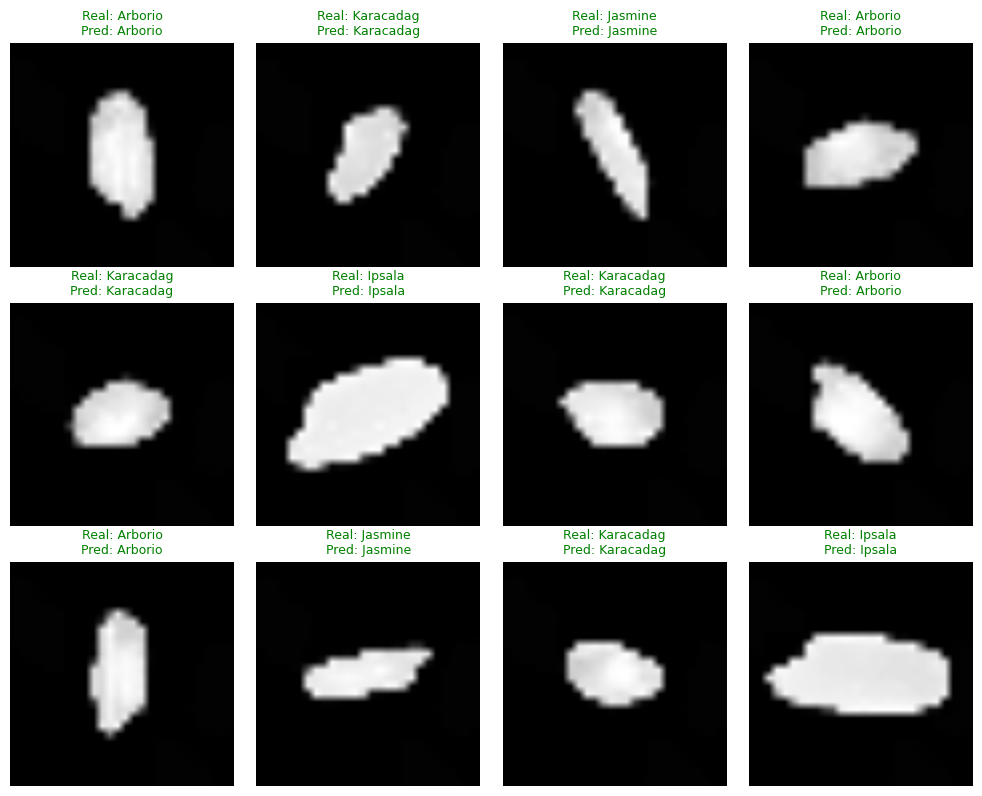

In [ ]:
# 2. VISUALIZACIÓN DE IMÁGENES CON PREDICCIONES

# Mapeo opcional de nombres de clases de arroz
nombres_clases = {0: 'Arborio', 1: 'Basmati', 2: 'Ipsala', 3: 'Jasmine', 4: 'Karacadag'}

# Seleccionar 12 muestras aleatorias del conjunto de prueba
np.random.seed(10)
indices_muestra = np.random.choice(len(X_test), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.ravel()

for i, idx in enumerate(indices_muestra):
    # Reconstruir la imagen de 784 píxeles a 28x28
    img_2d = X_test[idx].reshape(28, 28).numpy()

    clase_real = y_test[idx].item()
    clase_pred = preds_test[idx].item()

    # Asignar color verde si fue correcta, rojo si fue incorrecta
    color_titulo = 'green' if clase_real == clase_pred else 'red'

    axes[i].imshow(img_2d, cmap='gray')

    # Mostrar etiquetas numéricas o nombres si aplicas el diccionario
    label_real = nombres_clases.get(clase_real, f"Clase {clase_real}")
    label_pred = nombres_clases.get(clase_pred, f"Clase {clase_pred}")

    axes[i].set_title(f"Real: {label_real}\nPred: {label_pred}", color=color_titulo, fontsize=9)
    axes[i].axis('off')
    axes[i].imshow(img_2d, cmap='gray', interpolation='bilinear')

plt.tight_layout()
plt.show()